# Preprocessing

the csv file that should be used in here is found in data\interim\

### meal items 

In [1]:
#import libraries
import pandas as pd

In [2]:
#load csv files
joined_df=pd.read_csv('../data/interim/joined_data.csv')

In [ ]:
joined_df = joined_df.sort_values(by='date').reset_index(drop=True)

In [21]:
joined_df.tail()

,date,dou_code,meal_type_id,meal_items,resto_name,breakfast,launch,dinner
669923,2026-04-09,151,1,"حلويات جافة , حليب بالقهوة , عصير , ياغورت/قشدة",ANON_5c2150ddac80,50,233,213
669924,2026-04-09,151,1,"حلويات جافة , حليب بالقهوة , عصير , ياغورت/قشدة",ANON_a6fe8f441f2c,19,177,183
669925,2026-04-09,151,1,"حلويات جافة , حليب بالقهوة , عصير , ياغورت/قشدة",ANON_46abd12f70dd,15,3,62
669926,2026-04-09,151,2,"أرز مشكل , خبز , سلطة متنوعة , سمك/سردين معلب ...",ANON_5c2150ddac80,50,233,213
669927,2026-04-09,481,3,"شوربة , لحم قطع في الفرن (لحم قطع + بطاطا بالص...",ANON_93dd089ec13b,212,462,244


In [3]:
#look for null values in all columns 
null_values = joined_df.isnull().sum()
print(null_values)

date                    0
dou_code                0
meal_type_id            0
meal_items              0
n_distinct_items        0
meal_type               0
create_date             0
resto_name              0
id                      0
id_pro              12304
count                   0
breakfast               0
launch                  0
dinner                  0
dtype: int64


In [ ]:
#drop useless columns
columns_to_drop = ['meal_type','id_pro','id','count','create_date','n_distinct_items']
joined_df = joined_df.drop(columns=columns_to_drop)

In [20]:
#find the cardinality of each column
cardinality = joined_df.nunique()
print(cardinality)

date              734
dou_code           66
meal_type_id        3
meal_items      48638
resto_name        506
breakfast         941
launch           2336
dinner           1922
dtype: int64


In [23]:
mapping_df = pd.read_csv('meal_items_mapping_cleaned.csv')

In [25]:
mapping_df.tail()

,item,category_id,category_name
3777,يعورت معطر,11,Dairy & Cheese
3778,يعورت معطرة,11,Dairy & Cheese
3779,يغورت معطر,11,Dairy & Cheese
3780,ڤراتان,11,Cooked Dishes & Stews
3781,ڨراته,11,Cooked Dishes & Stews


In [26]:
item_to_cat = dict(zip(mapping_df['item'].str.strip(), mapping_df['category_name']))

In [27]:
all_16_categories = mapping_df['category_name'].unique()

In [ ]:
import re
def map_meal_to_categories(meal_text):
    if pd.isna(meal_text):
        return []
        
    # Split by +, /, commas, parentheses, or the Arabic words for "and" (و) / "or" (او/أو)
    parts = re.split(r'[\+\/\(\)\،\,]| او | أو | و ', str(meal_text))
    
    # Clean spaces and drop empty strings
    cleaned_items = [p.strip() for p in parts if p.strip()]
    
    # Map to categories 
    # (We use a 'set' because if a meal has two types of fruit, we only want one "Fruits" flag, not two)
    categories = set()
    for item in cleaned_items:
        cat = item_to_cat.get(item)
        if cat:
            categories.add(cat)
            
    return list(categories)

In [30]:
joined_df['category_list'] = joined_df['meal_items'].apply(map_meal_to_categories)

In [ ]:
# Generate the 16 binary columns
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer(classes=all_16_categories)
binary_matrix = mlb.fit_transform(joined_df['category_list'])

In [32]:
# Convert the matrix into a DataFrame with the 16 category names as headers
binary_df = pd.DataFrame(binary_matrix, columns=mlb.classes_, index=joined_df.index)

In [ ]:
joined_df = pd.concat([joined_df, binary_df], axis=1)

In [43]:
joined_df.head()

,date,dou_code,resto_name,breakfast,launch,dinner,Bread & Bakery,Rice & Pasta,Legumes,Poultry,...,Eggs,Dairy & Cheese,Vegetables & Salads,Soups & Broths,Cooked Dishes & Stews,Potato Dishes,Fruits,Sweets & Desserts,Beverages,Condiments & Spreads
0,2023-12-12,41,ANON_beae590631b8,0,6,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,2023-12-12,381,ANON_f70ee3e4559d,0,216,0,1,1,0,0,...,0,0,1,0,0,0,0,0,1,0
2,2023-12-12,381,ANON_f70ee3e4559d,0,216,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,2023-12-12,141,ANON_294c1f5ad3ee,0,2,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,2023-12-12,141,ANON_294c1f5ad3ee,0,2,0,1,1,0,0,...,0,1,1,0,0,0,0,1,0,0


In [ ]:
# change data type of date column to string to be used later on as a categorical feature 
joined_df['date'] = joined_df['date'].astype(str)

In [ ]:
#drop other useless columns
columns_to_drop = ['meal_type_id','category_list','meal_items']
joined_df = joined_df.drop(columns=columns_to_drop)

we drop meal_type_id since we are going to use MultiOutputRegressor and have a model for each target, one model for each meal type and the models are seperated so it will not provide any information

In [ ]:
print("Breakfast rows with 0:", joined_df[joined_df['breakfast'] == 0].shape[0])
print("Lunch rows with 0:", joined_df[joined_df['launch'] == 0].shape[0])
print("Dinner rows with 0:", joined_df[joined_df['dinner'] == 0].shape[0])

Breakfast rows with 0: 192407
Lunch rows with 0: 22336
Dinner rows with 0: 112565


In [47]:
joined_df.shape

(669928, 22)

In [48]:
joined_df[joined_df['launch'] == 0 & (joined_df['breakfast'] == 0) & (joined_df['dinner'] == 0)].shape[0]

22336

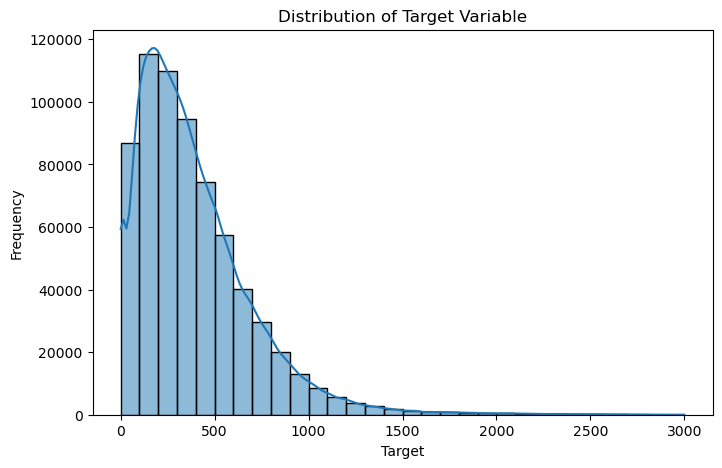

In [55]:
target = joined_df["launch"]

import matplotlib.pyplot as plt
import seaborn as sns
# Histogram + KDE
plt.figure(figsize=(8, 5))
sns.histplot(target, bins=30, kde=True)

plt.title("Distribution of Target Variable")
plt.xlabel("Target")
plt.ylabel("Frequency")

plt.show()